# Visualization of the L2A product

This notebook opens an hGRS L2A product (here the one written in [Processing an image](process_image.ipynb))
and shows maps, spectra and statistics over a region of interest. The last section gives the
interactive tools of [grstbx](https://github.com/Tristanovsk/grstbx) and holoviews, to be run in
Jupyter.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import rioxarray  # noqa: F401, enables the .rio accessor

In [2]:
file = 'L2A/ENMAP01-____L2A_hgrs-DT0000088121_20240817T102235Z_002_V010502_20250128T220420Z_V1.1.2.nc'
l2_prod = xr.open_dataset(file)
l2_prod

<xarray.Dataset> Size: 1GB
Dimensions:           (wl: 92, y: 1247, x: 1598, yc: 63, xc: 80)
Coordinates:
  * x                 (x) float64 13kB 2.431e+05 2.431e+05 ... 2.91e+05
    spatial_ref       int64 8B ...
    time              datetime64[ns] 8B ...
  * y                 (y) float64 10kB 4.8e+06 4.8e+06 ... 4.763e+06 4.763e+06
  * wl                (wl) float64 736B 418.4 424.0 ... 1.093e+03 1.105e+03
  * xc                (xc) float64 640B 2.433e+05 2.439e+05 ... 2.907e+05
  * yc                (yc) float64 504B 4.8e+06 4.799e+06 ... 4.763e+06
Data variables: (12/13)
    Rrs               (wl, y, x) float64 1GB ...
    brdfg_full        (y, x) float64 16MB ...
    tcwv              (yc, xc) float64 40kB ...
    tcwv_std          (yc, xc) float64 40kB ...
    aot_ref           (yc, xc) float64 40kB ...
    brdfg             (yc, xc) float64 40kB ...
    ...                ...
    brdfg_std         (yc, xc) float64 40kB ...
    aot_ref_smoothed  (yc, xc) float64 40kB ...
    water_pix_prop    (yc, xc) float64 40kB ...
    pressure          float64 8B ...
    to3c              float64 8B ...
    tno2c             float64 8B ...
Attributes: (12/42)
    description:                     PRISMA L2A-hGRS cube data
    L1C_product_name:                ENMAP01-____L1C-DT0000088121_20240817T10...
    acquisition_date:                2024-08-17 10:22:30.993191
    vnir_index:                      [  0   1   2   3   4   5   6   7   8   9...
    swir_index:                      [ 79  81  84  86  88  90  93  95  97  99...
    vnir_index_tokeep:               [ 0  1  2  3  4  5  6  7  8  9 10 11 12 ...
    ...                              ...
    to3c:                            0.0062910388223826885
    tno2c:                           3.0029445952095557e-06
    tch4c:                           0.009911714121699333
    psl:                             1013
    coef_abs_scat:                   0.35
    altitude:                        0

## Maps

The product is in the UTM projection of the L1C image (EPSG 326xx in the northern hemisphere, 327xx in
the southern hemisphere).

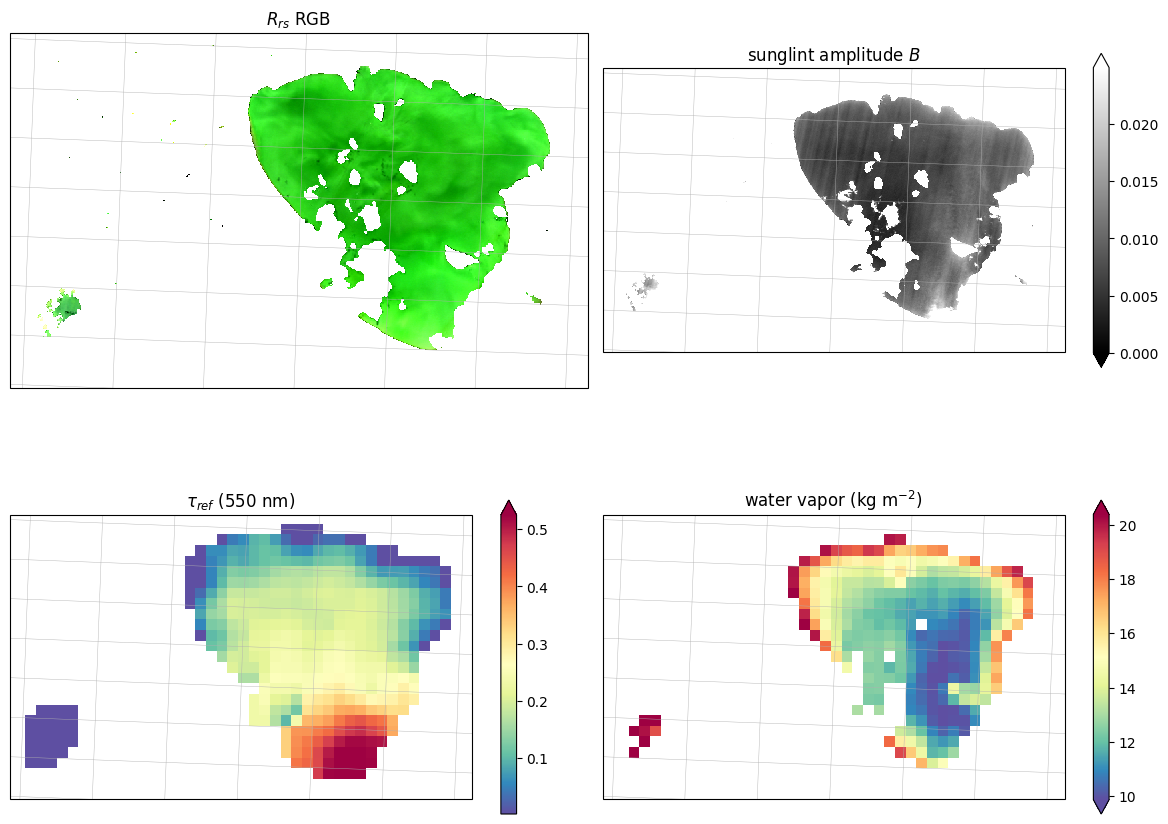

In [3]:
epsg = l2_prod.rio.crs.to_epsg()
proj = ccrs.UTM(epsg % 100, southern_hemisphere=(epsg // 100 == 327))

fig, axs = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={'projection': proj})
axs = axs.ravel()
l2_prod.Rrs.sel(wl=[665, 560, 470], method='nearest').plot.imshow(rgb='wl', robust=True, ax=axs[0])
axs[0].set_title('$R_{rs}$ RGB')
l2_prod.brdfg_full.plot.imshow(vmin=0, cmap=plt.cm.gray, robust=True, ax=axs[1],
                               cbar_kwargs={'shrink': 0.6, 'label': ''})
axs[1].set_title('sunglint amplitude $B$')
l2_prod.aot_ref_smoothed.plot.imshow(cmap=plt.cm.Spectral_r, robust=True, ax=axs[2],
                                     cbar_kwargs={'shrink': 0.6, 'label': ''})
axs[2].set_title(r'$\tau_{ref}$ (550 nm)')
l2_prod.tcwv.plot.imshow(cmap=plt.cm.Spectral_r, robust=True, ax=axs[3],
                         cbar_kwargs={'shrink': 0.6, 'label': ''})
axs[3].set_title('water vapor (kg m$^{-2}$)')
for ax in axs:
    ax.set_extent([247000, 273000, 4772000, 4788000], crs=proj)   # zoom on the lakes (UTM coordinates)
    ax.gridlines(draw_labels=False, lw=0.3)
plt.tight_layout()

## Statistics over a region of interest

Median, interquartile range and extreme values of $R_{rs}$ in a box of 1.5 km x 1.5 km at the center
of the lake (coordinates in the UTM projection of the product).

number of pixels: 2500


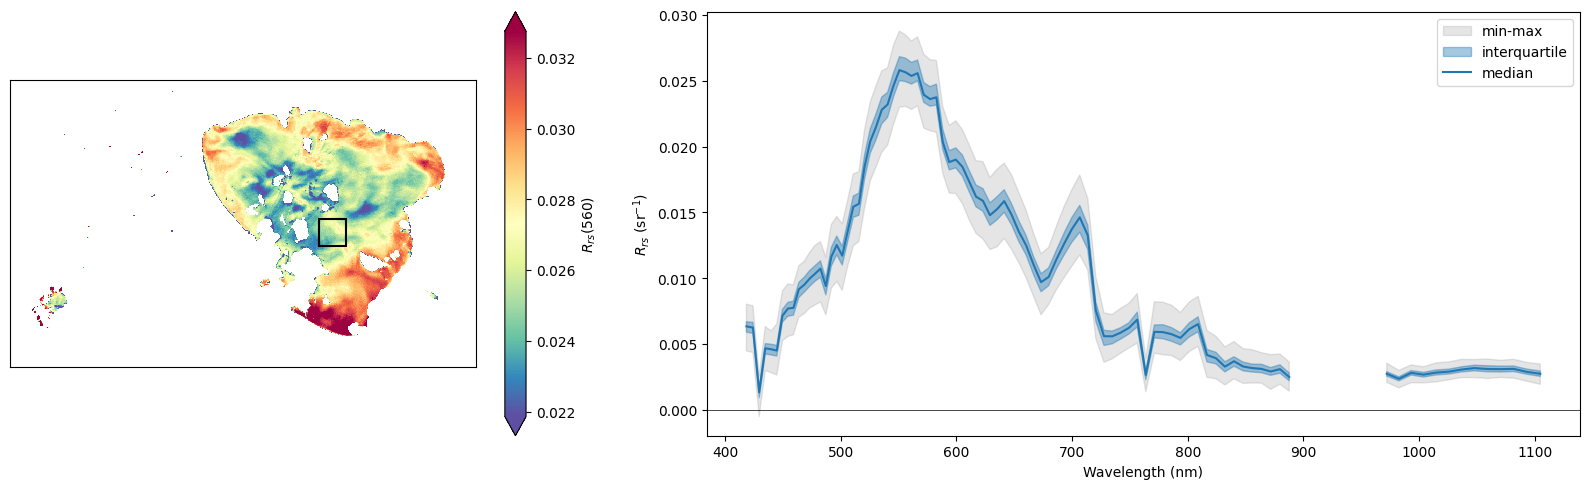

In [4]:
x0, y0, half_size = 265000, 4779500, 750
roi = l2_prod.Rrs.sel(x=slice(x0 - half_size, x0 + half_size),
                      y=slice(y0 + half_size, y0 - half_size))   # y is decreasing

stacked = roi.stack(pixel=['y', 'x']).dropna('pixel', how='all')
stats = xr.Dataset({'median': stacked.median('pixel'),
                    'q25': stacked.quantile(0.25, dim='pixel').drop_vars('quantile'),
                    'q75': stacked.quantile(0.75, dim='pixel').drop_vars('quantile'),
                    'min': stacked.min('pixel'),
                    'max': stacked.max('pixel')})
print('number of pixels:', stacked.sizes['pixel'])

fig, axs = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1, 1.5]})
l2_prod.Rrs.sel(wl=560, method='nearest').sel(x=slice(247000, 273000), y=slice(4788000, 4772000)).plot.imshow(
    cmap=plt.cm.Spectral_r, robust=True, ax=axs[0],
    cbar_kwargs={'label': '$R_{rs}(560)$'})
axs[0].add_patch(plt.Rectangle((x0 - half_size, y0 - half_size), 2 * half_size, 2 * half_size,
                               fill=False, color='k', lw=1.5))
axs[0].set(xticks=[], yticks=[], xlabel='', ylabel='', title='', aspect='equal')

ax = axs[1]
ax.fill_between(stats.wl, stats['min'], stats['max'], color='grey', alpha=0.2, label='min-max')
ax.fill_between(stats.wl, stats.q25, stats.q75, color='tab:blue', alpha=0.4, label='interquartile')
stats['median'].plot(ax=ax, color='tab:blue', label='median')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='Wavelength (nm)', ylabel='$R_{rs}$ (sr$^{-1}$)', title='')
ax.legend()
plt.tight_layout()

## Interactive tools

The following cells need a running Jupyter kernel (they are not executed in this documentation).

### grstbx spectral viewer

Browse the bands of $R_{rs}$ and click on the map to extract the spectra of points of interest (see
the animation on the [home page](../index.rst)).

In [ ]:
import panel as pn
from grstbx import visual

pn.extension()
v = visual.ViewSpectral(l2_prod.Rrs.isel(wl=range(0, 63, 5)), reproject=True)
v.minmax = [0, 0.1]
v.minmaxvalues = (0, 0.04)
v.visu()

Spectra of the points clicked on the map (`v.poi_stream`):

In [ ]:
import geopandas as gpd

points = v.poi_stream.data
points = gpd.GeoDataFrame(geometry=gpd.points_from_xy(points['x'], points['y']), crs=3857
                          ).to_crs(l2_prod.rio.crs)

fig, ax = plt.subplots(figsize=(10, 5))
for i, point in enumerate(points.geometry):
    l2_prod.Rrs.sel(x=point.x, y=point.y, method='nearest').plot(ax=ax, label=f'point {i}')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='Wavelength (nm)', ylabel='$R_{rs}$ (sr$^{-1}$)', title='')
ax.legend()

### Spectra of drawn boxes with holoviews

Draw boxes on the image (box edit tool) to plot the mean and standard deviation of $R_{rs}$ in each
box; the slider selects the band.

In [ ]:
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

param = 'Rrs'
raster = l2_prod[param]
ds = hv.Dataset(raster)
image = ds.to(hv.Image, ['x', 'y'], dynamic=True).opts(cmap='Spectral_r', colorbar=True, clim=(0, 0.04))

polys = hv.Polygons([])
box_stream = hv.streams.BoxEdit(source=polys)


def roi_stats(data, spread=False):
    if not data or not any(len(d) for d in data.values()):
        return hv.NdOverlay({0: hv.Curve([], 'Wavelength (nm)', param)})
    elements = {}
    for i, (x0, x1, y0, y1) in enumerate(zip(data['x0'], data['x1'], data['y0'], data['y1'])):
        selection = ds.select(x=(x0, x1), y=(y0, y1))
        mean = selection.aggregate('wl', np.nanmean).data
        if spread:
            std = selection.aggregate('wl', np.nanstd).data
            elements[i] = hv.Spread((mean.wl, mean[param], std[param]))
        else:
            elements[i] = hv.Curve((mean.wl, mean[param]), 'Wavelength (nm)', param)
    return hv.NdOverlay(elements)


# holoviews does not mix Curve and Spread in the same DynamicMap
mean = hv.DynamicMap(lambda data: roi_stats(data), streams=[box_stream])
std = hv.DynamicMap(lambda data: roi_stats(data, spread=True), streams=[box_stream])
vlines = hv.HoloMap({wl: hv.VLine(wl) for wl in raster.wl.values}, 'wl')

hv.output(widget_location='top_left')
(image * polys + (mean * std * vlines).relabel(param)).opts(
    opts.Image(width=600, height=500),
    opts.Curve(width=700, height=500, framewise=True, xlim=(400, 1100)),
    opts.Polygons(fill_alpha=0.2, color='green', line_color='black'),
    opts.VLine(color='black')).cols(2)